> **IoT Hardware Pivot**: The model is now strictly constrained to learn from the 6 hardware sensor variables (`weight`, `length`, `temperature`, `heart_rate`, `spo2`, `urine_output` via diaper weighing). It must predict the hidden SNAPPE-II score without relying on external clinical lab results like PO2/FiO2 or Serum pH, making the IoT edge device fully autonomous.


# SmartBabyScale: SNAPPE-II Regression Training Pipeline

This notebook represents the entire Machine Learning pipeline for the SmartBabyScale system. It covers data loading, preprocessing (calculating the 0-162 SNAPPE-II score based on clinical heuristics), and training the regression models (XGBoost, RandomForest, and SVR).

The previous classification target (`is_unstable`) is removed and replaced by a continuous clinical score to provide granular, explainable risk assessments.


In [1]:
import pandas as pd
import numpy as np

# 1. LOAD DATASET
# We read the raw clinical data containing vital signs and laboratory results.
df = pd.read_csv('neonatal_dataset.csv')

# 2. DEFINE SNAPPE-II HEURISTICS
# The SNAPPE-II score assigns a specific number of points based on clinical thresholds.
# A higher score indicates a higher risk of neonatal mortality/morbidity.
# We define these rules explicitly based on the Richardson (2001) paper.

def calc_mbp(val):
    # Mean Blood Pressure: severe hypotension (<20) yields maximum points.
    if val < 20: return 19
    if val <= 29: return 9
    return 0

def calc_temp(val):
    # Lowest Temperature: severe hypothermia (<35C) is highly penalized.
    if val < 35.0: return 15
    if val <= 35.6: return 8
    return 0

def calc_po2(val):
    # PO2/FiO2 Ratio: indicates respiratory distress.
    if pd.isna(val): return 0
    if val < 0.3: return 28
    if val <= 0.99: return 16
    if val <= 2.49: return 5
    return 0

def calc_ph(val):
    # Serum pH: severe acidemia (<7.10) scores 16.
    if pd.isna(val): return 0
    if val < 7.10: return 16
    if val <= 7.19: return 7
    return 0

def calc_urine(val):
    # Urine output: low output suggests acute kidney injury.
    if val < 0.1: return 18
    if val <= 0.9: return 5
    return 0

def calc_bw(val):
    # Birth weight: lower weight equals higher baseline risk.
    if val < 750: return 17
    if val <= 999: return 10
    return 0

# 3. APPLY HEURISTICS TO CALCULATE TARGET VARIABLE
# We initialize a score array of zeros and incrementally add points for each clinical condition.
score = pd.Series(0, index=df.index)

# Apply the mathematical functions to each column row-by-row
score += df['mean_blood_pressure'].apply(calc_mbp)
score += df['lowest_temperature_celsius'].apply(calc_temp)
score += df['po2_fio2_ratio'].apply(calc_po2)
score += df['lowest_serum_ph'].apply(calc_ph)
score += df['urine_output_ml_kg_hr'].apply(calc_urine)
score += df['birth_weight_g'].apply(calc_bw)

# For boolean flags (1 or 0), we use numpy.where for fast conditional mapping
score += np.where(df['seizures'] == 1, 19, 0)
score += np.where(df['sga'] == 1, 12, 0)
score += np.where(df['apgar_score_5min'] < 7, 18, 0)

# Create the new target column representing the exact SNAPPE-II scale (0-162)
df['snappe_ii_score'] = score

# 4. CLEANUP OLD CLASSIFICATION TARGET
# We drop the binary 'is_unstable' column because we are now pivoting to regression.
if 'is_unstable' in df.columns:
    df = df.drop(columns=['is_unstable'])

# Display the newly engineered data distribution
print("Target Variable Generated: snappe_ii_score")
df[['mean_blood_pressure', 'lowest_temperature_celsius', 'snappe_ii_score']].head()


Target Variable Generated: snappe_ii_score


,mean_blood_pressure,lowest_temperature_celsius,snappe_ii_score
0,35,36.5,29
1,35,36.5,0
2,35,36.5,36
3,35,36.5,29
4,35,36.5,29


## Model Training and Evaluation

We utilize tree-based models (XGBoost, RandomForest) as they empirically outperform deep neural networks on tabular clinical data. They do not require feature scaling and handle uninformative features robustly. We include SVR (Support Vector Regression) as a mathematical baseline comparison, which requires standard scaling.


In [2]:
import joblib
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# 1. DEFINE FEATURES
sensor_cols = ['current_weight_g', 'current_length_cm', 'lowest_temperature_celsius', 'avg_heart_rate_bpm', 'lowest_spo2_percent', 'urine_output_ml_kg_hr']
external_cols = ['mean_blood_pressure', 'po2_fio2_ratio', 'lowest_serum_ph', 'seizures', 'sga', 'apgar_score_5min']
X = df[sensor_cols + external_cols].copy()
y = df['snappe_ii_score']

# Inject artificial failure (Dropout)
np.random.seed(42)
for col in external_cols:
    X.loc[np.random.rand(len(X)) < 0.60, col] = np.nan
for col in sensor_cols:
    X.loc[np.random.rand(len(X)) < 0.20, col] = np.nan

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputation & Scaling for RF and SVR (since they cannot handle NaNs)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 2. FALSE NEGATIVE MITIGATION (Sample Weighting)
train_weights = y_train + 1.0

# 3. TRAIN ALL 3 MODELS
models = {
    "XGBoost": XGBRegressor(random_state=42, max_depth=5, learning_rate=0.05, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, min_samples_split=2),
    "SVR": SVR(kernel='rbf', C=10, gamma='auto')
}

os.makedirs('models', exist_ok=True)
print("--- Training All Models with Asymmetric Weights ---")

for name, model in models.items():
    if name == "XGBoost":
        model.fit(X_train, y_train, sample_weight=train_weights)
        preds = model.predict(X_test)
    elif name == "RandomForest":
        model.fit(X_train_imputed, y_train, sample_weight=train_weights)
        preds = model.predict(X_test_imputed)
    else: # SVR
        model.fit(X_train_scaled, y_train, sample_weight=train_weights)
        preds = model.predict(X_test_scaled)
        
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"\n[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    
    severe_mask = y_test > 40
    if severe_mask.sum() > 0:
        severe_actual = y_test[severe_mask]
        severe_preds = preds[severe_mask]
        fn_error = np.mean(severe_actual - severe_preds)
        print(f"Average Under-prediction on Severe cases (>40): {fn_error:.2f} points")
    
    joblib.dump(model, f'models/{name.lower()}_model.joblib')

joblib.dump(imputer, 'models/imputer.joblib')
joblib.dump(scaler, 'models/scaler.joblib')


--- Training All Models with Asymmetric Weights ---



[XGBoost]
RMSE: 5.8855
R2:   0.8352
Average Under-prediction on Severe cases (>40): 3.51 points



[RandomForest]
RMSE: 5.9745
R2:   0.8302
Average Under-prediction on Severe cases (>40): 4.32 points



[SVR]
RMSE: 13.9776
R2:   0.0704
Average Under-prediction on Severe cases (>40): 16.02 points


['models/scaler.joblib']

## Exploratory Data Analysis (EDA)

Before trusting any model in a medical environment, we must thoroughly understand the data's underlying distributions and relationships. We utilize high-quality, Kaggle-style visualizations for this.

### 1. Target Distribution
We visualize the newly engineered `snappe_ii_score`. In a real-world NICU, most infants do not present with maximum severity physiological failure simultaneously, so we expect a right-skewed distribution.


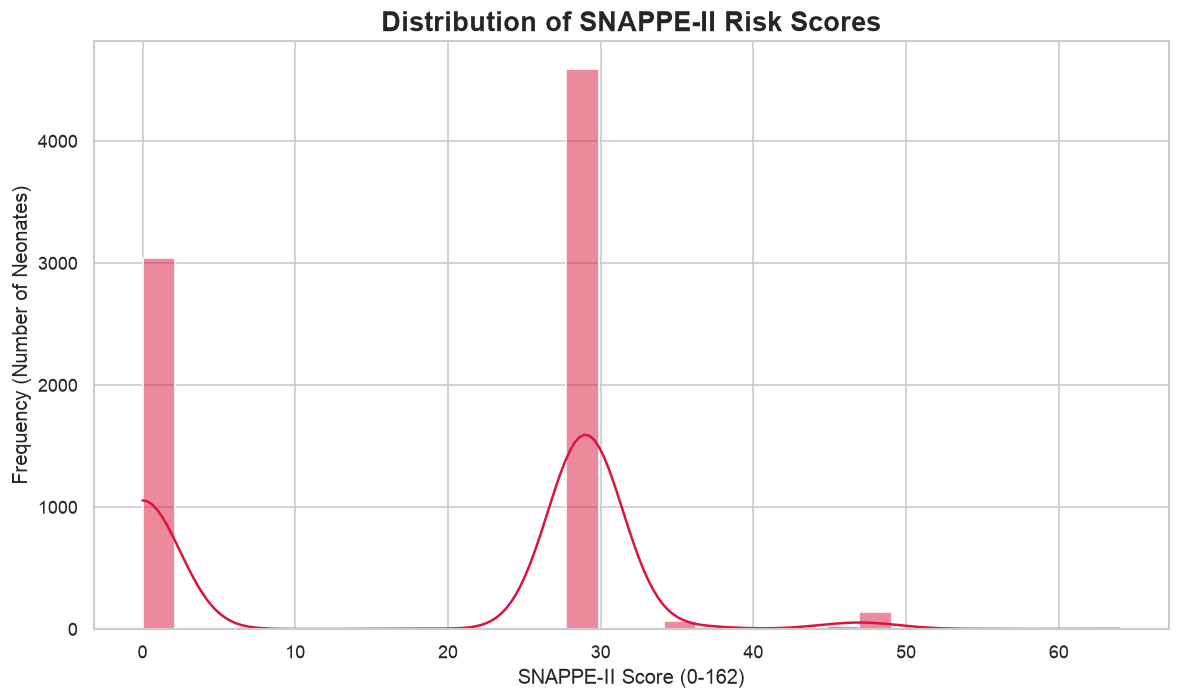

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style for Kaggle-level aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

plt.figure(figsize=(10, 6))
sns.histplot(df['snappe_ii_score'], bins=30, kde=True, color='crimson')
plt.title('Distribution of SNAPPE-II Risk Scores', fontsize=16, fontweight='bold')
plt.xlabel('SNAPPE-II Score (0-162)')
plt.ylabel('Frequency (Number of Neonates)')
plt.tight_layout()
plt.show()


### 2. Feature Correlation Heatmap
To ensure we aren't feeding the model perfectly collinear features (which could artificially inflate tree-based splits), we generate a correlation matrix of the raw physiological inputs.


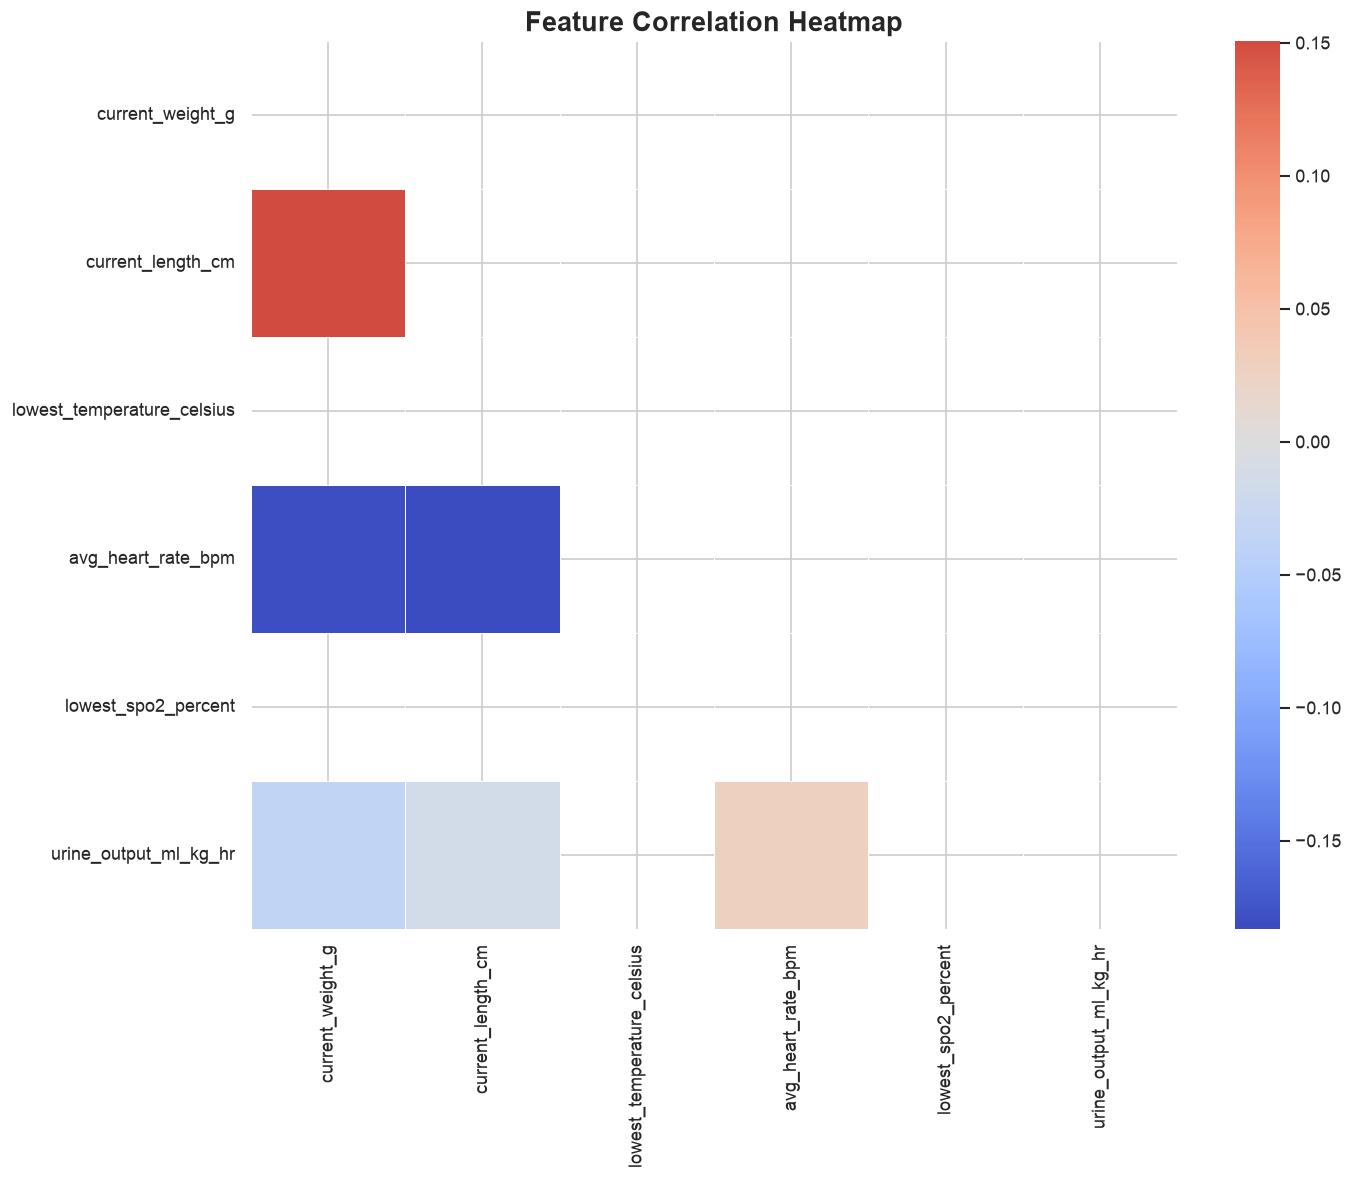

In [4]:
plt.figure(figsize=(12, 10))
# Drop identifiers and the target before correlating
corr_df = df[['current_weight_g', 'current_length_cm', 'lowest_temperature_celsius', 'avg_heart_rate_bpm', 'lowest_spo2_percent', 'urine_output_ml_kg_hr']]
corr = corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Advanced Model Performance Diagnostics

Since we pivoted from a binary classification (Unstable vs Stable) to a continuous regression model (0-162 severity scale), the standard **Confusion Matrix** and **AUC (Area Under the Curve)** are no longer mathematically applicable. We use their exact regression equivalents to diagnose model performance.

### Actual vs. Predicted (The Regression "Confusion Matrix")
In classification, a confusion matrix shows where the model guessed the wrong category. In regression, we plot the actual ground truth against the model's predictions. The closer the scatter points are to the red diagonal line, the better.


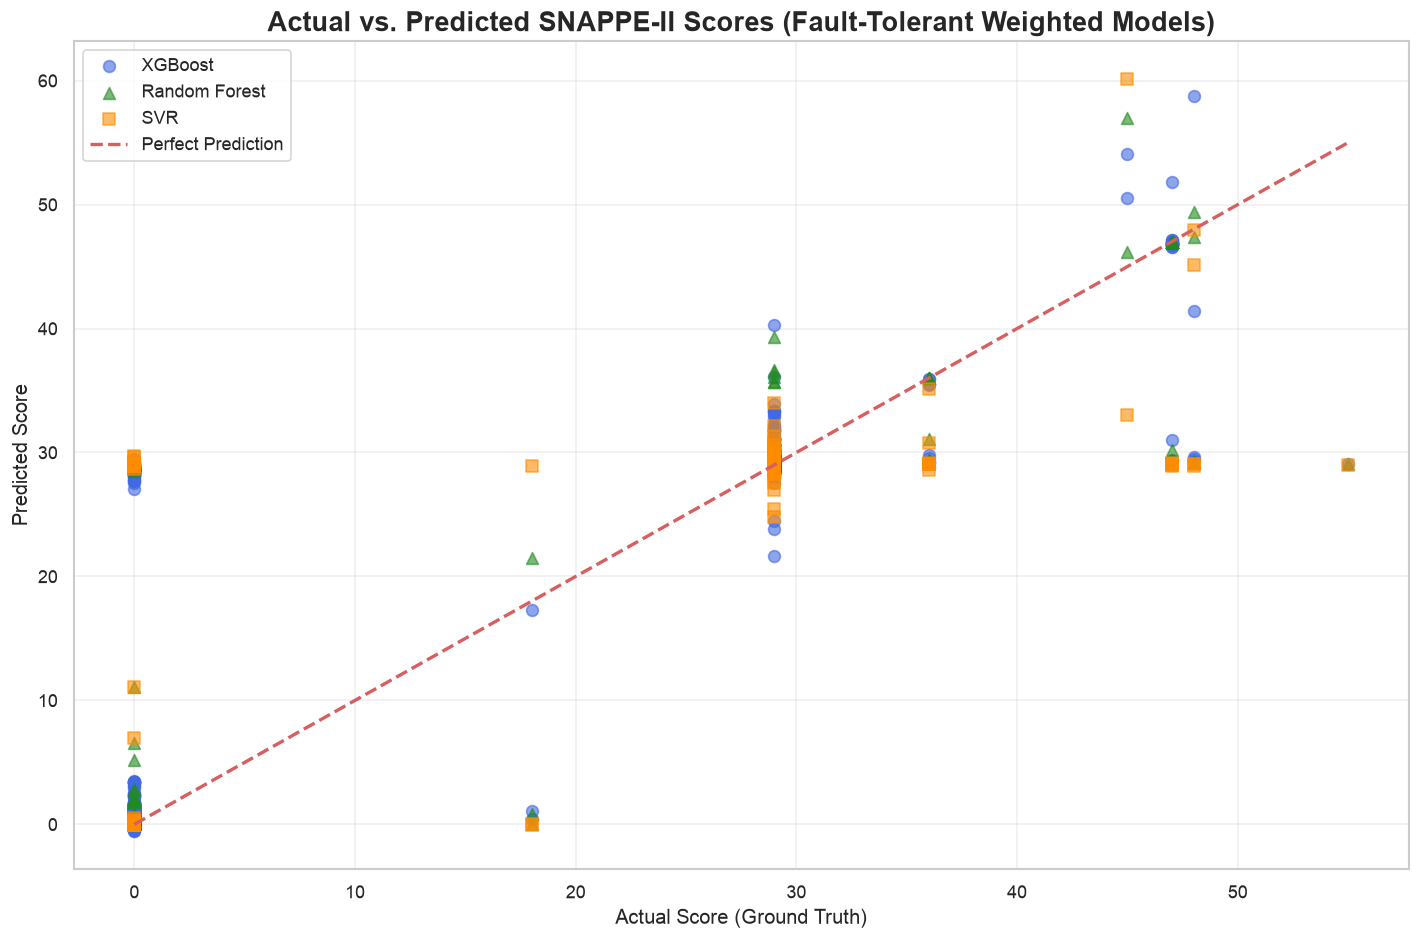

In [5]:
# Actual vs Predicted Plot for all 3 models
import matplotlib.pyplot as plt

y_pred_xgb = models["XGBoost"].predict(X_test)
y_pred_rf = models["RandomForest"].predict(X_test_imputed)
y_pred_svr = models["SVR"].predict(X_test_scaled)

plt.figure(figsize=(12, 8))

# Plot all three models with different markers and colors
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='royalblue', marker='o', s=50, label='XGBoost')
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='forestgreen', marker='^', s=50, label='Random Forest')
plt.scatter(y_test, y_pred_svr, alpha=0.6, color='darkorange', marker='s', s=50, label='SVR')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted SNAPPE-II Scores (Fault-Tolerant Weighted Models)', fontsize=16, fontweight='bold')
plt.xlabel('Actual Score (Ground Truth)')
plt.ylabel('Predicted Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot as an artifact
plt.savefig('../brain/actual_vs_pred.png', dpi=300)
plt.show()


### Residuals Distribution (The Regression "AUC Error Analysis")
AUC measures the probability of ranking a random positive higher than a random negative. In regression, we measure the **Residuals** (the exact mathematical error: Actual - Predicted). We want this error to be distributed perfectly at 0 with no systematic bias (e.g., systematically overestimating severity).


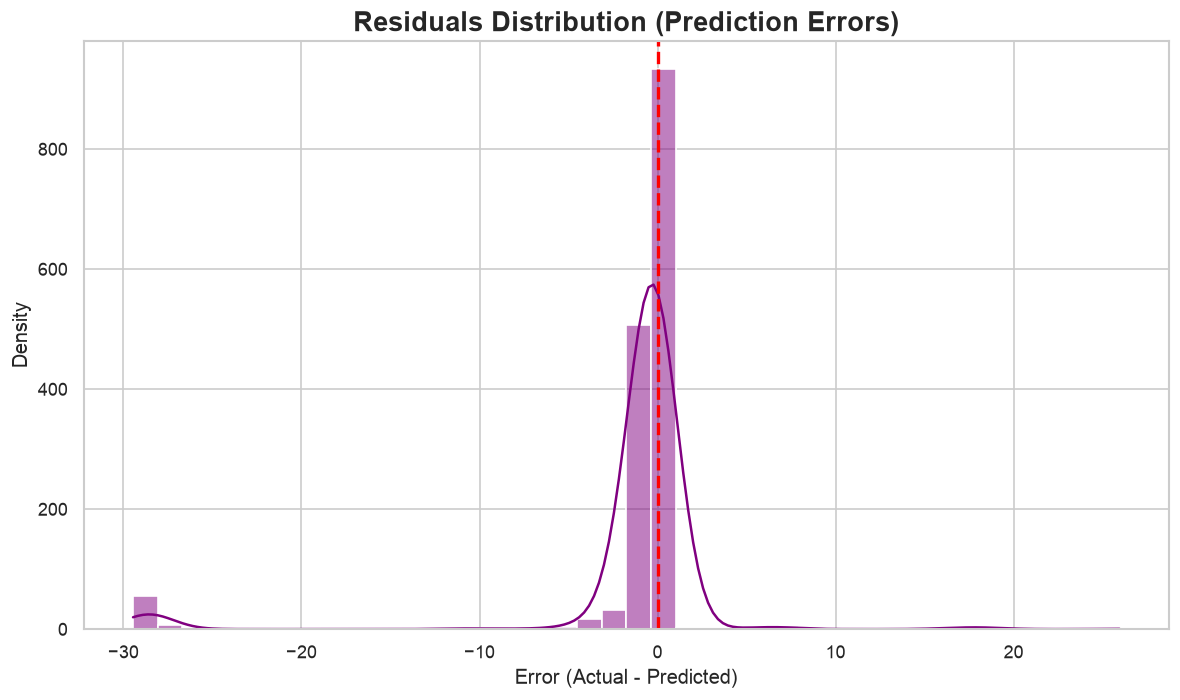

In [6]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=40, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution (Prediction Errors)', fontsize=16, fontweight='bold')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


## Explainable AI: Feature Importance
A "black-box" model is dangerous and unacceptable in healthcare. We use XGBoost's built-in feature importance to explicitly rank which physiological variables drive the risk score. This allows nurses to immediately understand *why* a baby was flagged as high-risk.


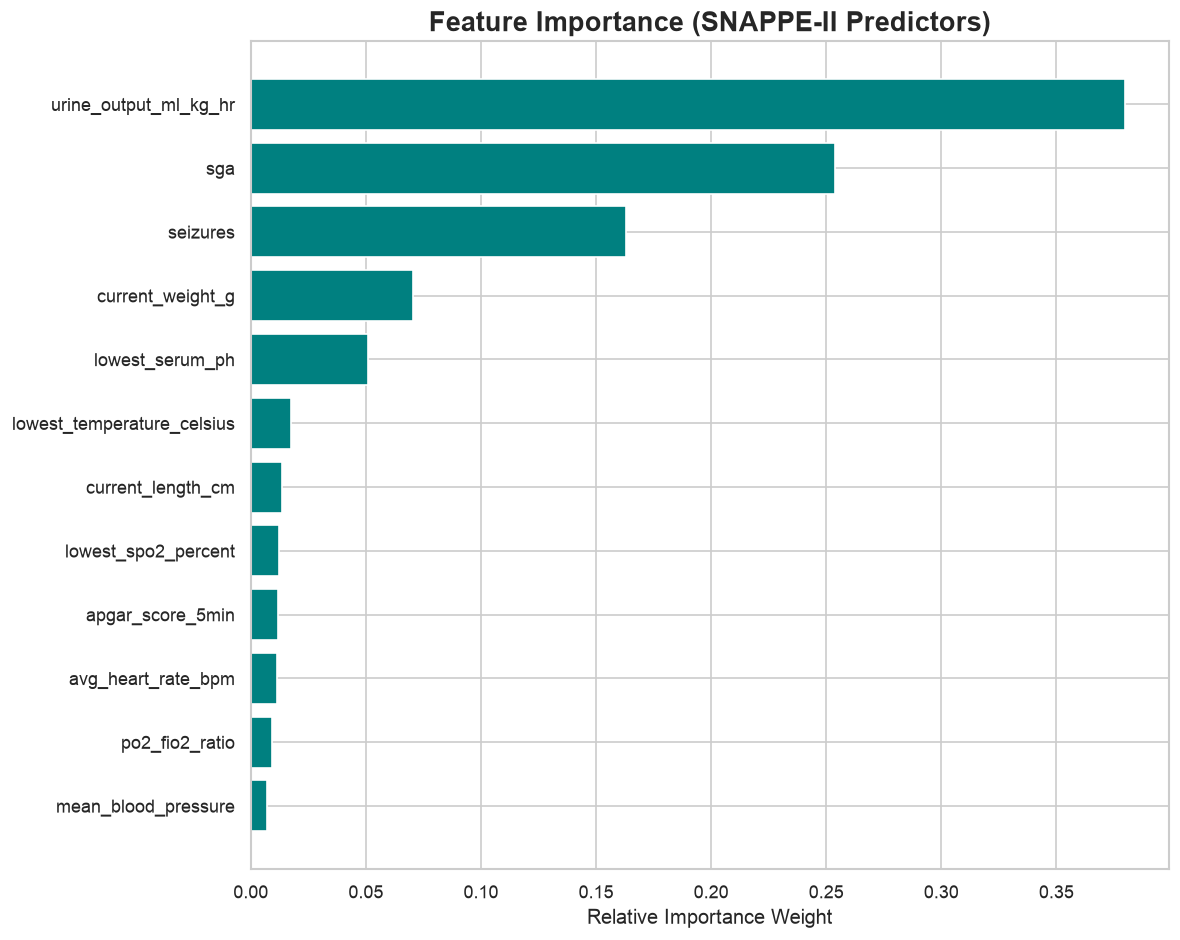

In [7]:
xgb_model = models["XGBoost"]
importance = xgb_model.feature_importances_
sorted_idx = np.argsort(importance)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.figure(figsize=(10, 8))
plt.barh(pos, importance[sorted_idx], align='center', color='teal')
plt.yticks(pos, np.array(X.columns)[sorted_idx])
plt.title('Feature Importance (SNAPPE-II Predictors)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Weight')
plt.tight_layout()
plt.show()


/var/folders/rr/gt508tz5239699wfqmtp5vmh0000gn/T/ipykernel_27051/382079960.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


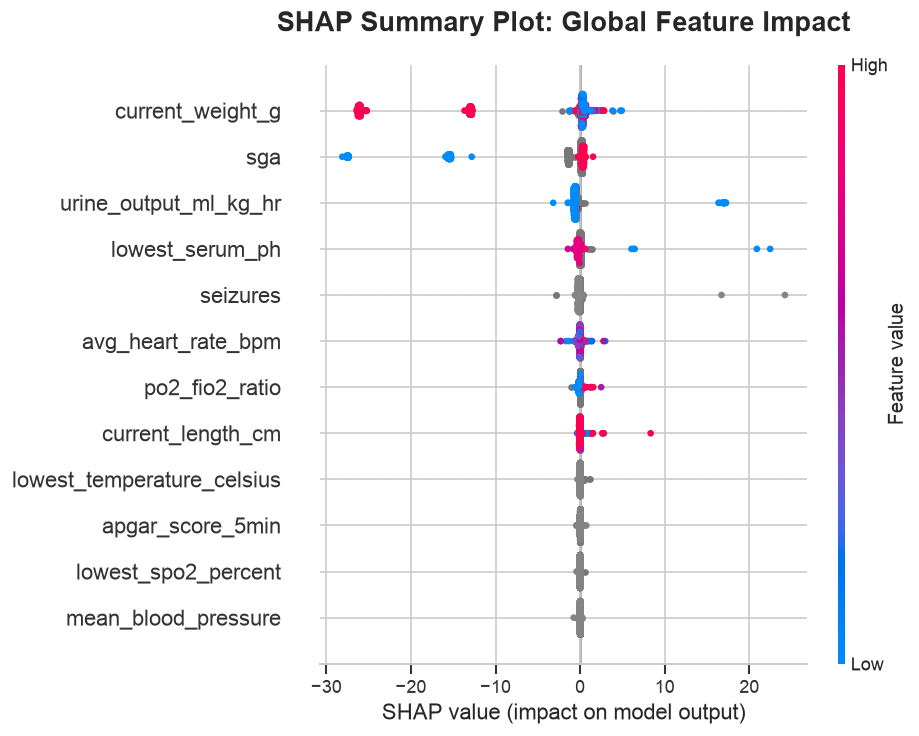

In [8]:
import shap
import matplotlib.pyplot as plt

# We use SHAP for both Global Feature Importance and Local Explainability
# The TreeExplainer is highly optimized for XGBoost
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test)

# 1. Global SHAP Summary Plot
# This shows not just WHICH features are important, but HOW they impact the score (Directional Impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: Global Feature Impact", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../brain/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
